In [1]:
#1.导入库和防止中文乱码
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

#2.读取数据
df = pd.read_csv('../data/clean_data.csv', parse_dates=['order_purchase_timestamp'])

In [2]:
#RFM三个核心指标  R:Recency 最近购买时间    F：Frequency  购买次数   M：Monetary  消费金额
#获取最大日期  （作为计算基准）
max_data = df['order_purchase_timestamp'].max()  #找到整个订单最晚下单的日期作为基准

#分组聚合计算RFM
rfm = df.groupby('customer_unique_id').agg(
    R=('order_purchase_timestamp',lambda x:(max_data - x.max()).days),
    F=('order_id','nunique'),
    M=('price','sum')
).reset_index()

In [3]:
rfm

,customer_unique_id,R,F,M
0,0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90
2,0000f46a3911fa3c0805444483337064,541,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,292,1,180.00
...,...,...,...,...
95415,fffcf5a5ff07b0908bd4e2dbc735a684,451,1,1570.00
95416,fffea47cd6d3cc0a88bd621562a9d061,266,1,64.89
95417,ffff371b4d645b6ecea244b27531430a,572,1,89.90
95418,ffff5962728ec6157033ef9805bacc48,123,1,115.00


In [5]:
#3.RFM打分（1-4）
rfm['R_score'] = pd.qcut(rfm['R'],4,labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['F'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['M'].rank(method='first'), 4, labels=[1,2,3,4])

In [8]:
#用户分层
def rfm_segment(row):
    R = row['R_score']
    F = row['F_score']
    M = row['M_score']

    if R >=3 and F >=3 and M >=3:
        return '高价值用户'
    elif R >=3 and F <3 and M >=3:
        return '潜力用户'
    elif R <3 and F >=3 and M >=3:
        return '流失风险用户'
    else:
        return '低价值用户'

rfm['user_type'] = rfm.apply(rfm_segment, axis=1)

In [9]:
#统计用户分布
user_count = rfm['user_type'].value_counts()

In [10]:
user_count

user_type
低价值用户     59350
高价值用户     12362
流失风险用户    11929
潜力用户      11779
Name: count, dtype: int64

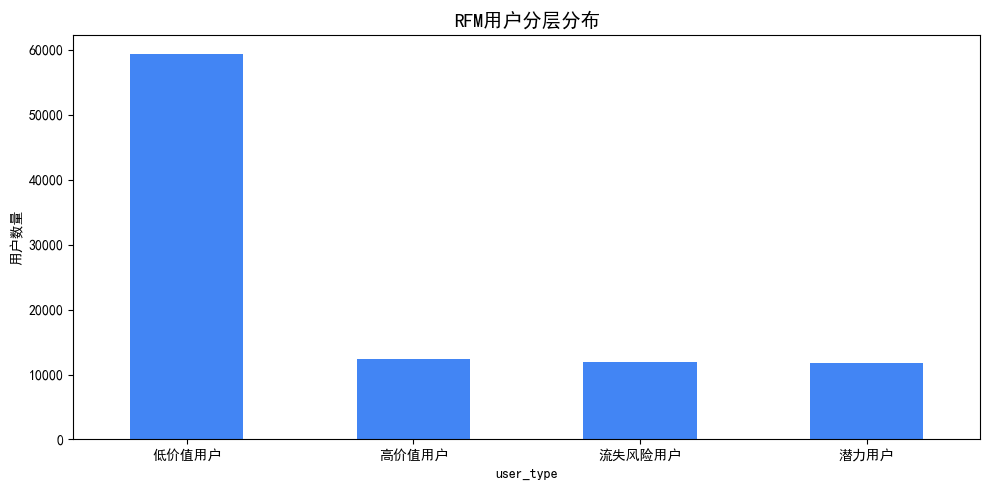

In [11]:
#6.绘制矩阵图
plt.figure(figsize=(10,5))
user_count.plot(kind='bar', color='#4285F4')

plt.title('RFM用户分层分布', fontsize=14)
plt.ylabel('用户数量')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../visualizations/rfm_user_segment.png', dpi=300)
plt.show()

### RFM逻辑总结

1. 算出每个用户R（最近购买）,F（频率）,M（总金额）
2. 给每个指标打分
3. 根据分数划分4类用户
4. 绘制柱状图，根据不同类型用户制定不同运营策略

### 业务建议

1. 针对高价值用户：重点留存，锁定核心收入  建立专属VIP体系，给予专属折扣，优先物流，售后等特权，避免这类核心用户流失
2. 针对潜力用户：重点转化，培养复购习惯  推送复购满减卷，加大优惠力度，引导其购买频率，将 “一次性高消费用户” 转化为 “高频复购用户”，破解 Cohort 次月留存极低的问题
3. 针对流失风险用户：低成本召回，尝试挽回  推送专属的优惠卷，提高优惠力度，做到薄利多销，重点唤醒其过往消费需求；若召回失败，也无需投入过多资源
4. 针对低价值用户：低成本运营，筛选潜力群体   派送相对合适的优惠卷，低成本商品推荐，唤醒消费意愿